In [ ]:
!pip install -q torchvision
!ls /kaggle/input/datasets/rarescocosila/proiect-iava/classical_model_builders.py

In [ ]:
import sys
sys.path.append("/kaggle/input/datasets/rarescocosila/proiect-iava")

In [6]:
import importlib
import random

import matplotlib.pyplot as plt
import pandas as pd
import torch

import classical_model_builders
import detection_utils
import utils as utils_module

importlib.reload(classical_model_builders)
importlib.reload(detection_utils)
importlib.reload(utils_module)

from classical_model_builders import build_maskrcnn_model
from detection_utils import build_instance_dataloaders, detection_output_to_multiclass_mask, evaluate_maskrcnn_segmentation, resize_multiclass_mask, run_maskrcnn_training_epoch, run_maskrcnn_validation_epoch
from utils import (
    SEED,
    benchmark_model,
    build_experiment_result_row,
    build_mask_from_record,
    build_optimization_profile,
    count_trainable_parameters,
    create_optimizer,
    create_scheduler,
    device,
    get_protocol_splits,
    load_image_as_rgb,
    load_segmentation_checkpoint,
    overlay_multiclass_mask,
    prepare_model_for_optimizations,
    seed_everything,
    summarize_protocol_splits,
)
seed_everything(SEED)

In [7]:
IMG_SIZE = 512
BATCH_SIZE = 1
EPOCHS = 6
LR = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0
REFRESH_METADATA = True
SELECTED_SOURCES = ['severstal', 'neu', 'kolektor']
MAX_VAL_SEG_SAMPLES = 120
MAX_TEST_SEG_SAMPLES = 120
SCORE_THRESHOLD = 0.5
CHECKPOINT_PATH = 'mask_rcnn_merged_best.pth'
NUM_VIS_SAMPLES = 4
ACTIVE_PROFILE = build_optimization_profile(
    channels_last=False,
    compile_model=False,
    gradient_checkpointing=False,
    grad_accumulation_steps=2,
    max_grad_norm=1.0,
    persistent_workers=False,
    prefetch_factor=None,
)
ACTIVE_PROFILE

{'amp_mode': 'fp16',
 'channels_last': False,
 'compile_model': False,
 'compile_mode': 'default',
 'gradient_checkpointing': False,
 'grad_accumulation_steps': 2,
 'max_grad_norm': 1.0,
 'ema_decay': None,
 'persistent_workers': False,
 'prefetch_factor': None}

In [9]:
import utils
from pathlib import Path

BASE = Path("/kaggle/input/datasets/rarescocosila/proiect-iava/dataset-iava")

utils.SEVERSTAL_ROOT = BASE / "severstal-steel-defect-detection"
utils.NEU_ROOT = BASE / "NEU-DET_data"
utils.KOLEKTOR_ROOT = BASE / "kolektor_data"

utils.TRAIN_DIR = f'{utils.SEVERSTAL_ROOT}/train_images'
utils.TRAIN_CSV = f'{utils.SEVERSTAL_ROOT}/train.csv'
utils.TEST_DIR = f'{utils.SEVERSTAL_ROOT}/test_images'

utils.build_severstal_metadata.__defaults__ = (
    utils.TRAIN_CSV,
    utils.TRAIN_DIR
)

build_severstal_metadata = utils.build_severstal_metadata

In [10]:
metadata, train_df, val_df, test_df = get_protocol_splits(random_state=SEED, refresh_cache="/kaggle/working/merged_metadata.csv")
train_df = train_df[train_df['source'].isin(SELECTED_SOURCES)].reset_index(drop=True)
val_df = val_df[val_df['source'].isin(SELECTED_SOURCES)].reset_index(drop=True)
test_df = test_df[test_df['source'].isin(SELECTED_SOURCES)].reset_index(drop=True)
display(summarize_protocol_splits(pd.concat([train_df, val_df, test_df], ignore_index=True)))

,protocol_split,source,images,defect_images,clean_images
0,train,kolektor,2097,221,1876
1,train,neu,863,863,0
2,train,severstal,10054,5333,4721
3,val,kolektor,234,25,209
4,val,neu,96,96,0
5,val,severstal,1257,666,591
6,test_final,kolektor,1004,110,894
7,test_final,neu,240,240,0
8,test_final,severstal,1257,667,590


In [13]:
train_dataset, val_dataset, train_loader, val_loader = build_instance_dataloaders(
    train_df=train_df,
    val_df=val_df,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    return_metadata=False,
    persistent_workers=ACTIVE_PROFILE['persistent_workers'],
    prefetch_factor=ACTIVE_PROFILE['prefetch_factor'],
)
test_dataset = build_instance_dataloaders(
    train_df=train_df.head(4),
    val_df=test_df,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=0,
    return_metadata=False,
)[1]

In [14]:
model = build_maskrcnn_model()
model, opt_info = prepare_model_for_optimizations(
    model,
    channels_last=ACTIVE_PROFILE['channels_last'],
    compile_model=ACTIVE_PROFILE['compile_model'],
    compile_mode=ACTIVE_PROFILE['compile_mode'],
    gradient_checkpointing=ACTIVE_PROFILE['gradient_checkpointing'],
)
optimizer = create_optimizer(model, name='adamw', lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = create_scheduler(optimizer, name='cosine', epochs=EPOCHS)
trainable_params = count_trainable_parameters(model)

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 214MB/s] 


In [15]:
history = {'epoch': [], 'train_loss': [], 'val_dice': [], 'val_iou': [], 'avg_pred_instances': []}
best_dice = float('-inf')
for epoch in range(EPOCHS):
    train_metrics = run_maskrcnn_training_epoch(model, train_loader, optimizer, device=device, grad_accumulation_steps=ACTIVE_PROFILE['grad_accumulation_steps'], max_grad_norm=ACTIVE_PROFILE['max_grad_norm'], show_progress=True, progress_desc=f'maskrcnn train {epoch+1}/{EPOCHS}')
    aux_val = run_maskrcnn_validation_epoch(model, val_loader, device=device, show_progress=True, progress_desc=f'maskrcnn val {epoch+1}/{EPOCHS}')
    seg_val = evaluate_maskrcnn_segmentation(model, val_dataset, device=device, score_threshold=SCORE_THRESHOLD, max_samples=MAX_VAL_SEG_SAMPLES, show_progress=True, progress_desc=f'maskrcnn seg val {epoch+1}/{EPOCHS}')
    scheduler.step()
    history['epoch'].append(epoch + 1)
    history['train_loss'].append(train_metrics['loss'])
    history['val_dice'].append(seg_val['dice'])
    history['val_iou'].append(seg_val['iou'])
    history['avg_pred_instances'].append(aux_val['avg_pred_instances'])
    print(f"epoch {epoch+1}/{EPOCHS} | train_loss={train_metrics['loss']:.4f} val_dice={seg_val['dice']:.4f} val_iou={seg_val['iou']:.4f}")
    if seg_val['dice'] > best_dice:
        best_dice = seg_val['dice']
        torch.save({'model_state_dict': model.state_dict(), 'history': history}, CHECKPOINT_PATH)

maskrcnn train 1/6:   0%|          | 0/13014 [00:00<?, ?it/s]

maskrcnn val 1/6:   0%|          | 0/1587 [00:00<?, ?it/s]

maskrcnn seg val 1/6:   0%|          | 0/120 [00:00<?, ?it/s]

epoch 1/6 | train_loss=0.6031 val_dice=0.8676 val_iou=0.8572


maskrcnn train 2/6:   0%|          | 0/13014 [00:00<?, ?it/s]

...

epoch 5/6 | train_loss=0.3772 val_dice=0.9134 val_iou=0.8976


maskrcnn train 6/6:   0%|          | 0/13014 [00:00<?, ?it/s]

maskrcnn val 6/6:   0%|          | 0/1587 [00:00<?, ?it/s]

maskrcnn seg val 6/6:   0%|          | 0/120 [00:00<?, ?it/s]

epoch 6/6 | train_loss=0.3405 val_dice=0.9188 val_iou=0.9042


In [16]:
load_segmentation_checkpoint(model, 'mask_rcnn_merged_best.pth', prefer_ema=False)
test_metrics = evaluate_maskrcnn_segmentation(model, test_dataset, device=device, score_threshold=0.5, max_samples=120)
test_metrics

maskrcnn_seg_eval:   0%|          | 0/120 [00:00<?, ?it/s]

{'dice': 0.9362608184417088, 'iou': 0.9201379025975863, 'samples': 120}

,epoch,train_loss,val_dice,val_iou,avg_pred_instances
0,1,0.603084,0.867566,0.857182,1.504726
1,2,0.506998,0.869257,0.856706,2.059861
2,3,0.464479,0.910090,0.896525,1.476371
3,4,0.419506,0.917988,0.903835,1.584121
4,5,0.377243,0.913357,0.897558,1.903592
5,6,0.340453,0.918811,0.904181,1.754883


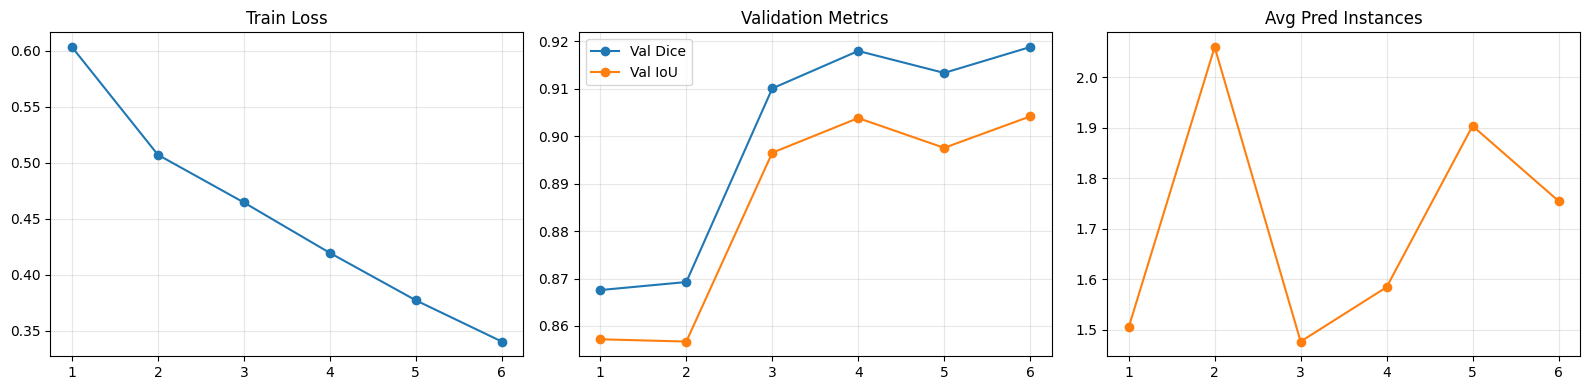

In [17]:
history_df = pd.DataFrame(history)
history_df.to_csv('mask_rcnn_merged_history.csv', index=False)
display(history_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o')
axes[0].set_title('Train Loss')
axes[0].grid(True, alpha=0.3)
axes[1].plot(history_df['epoch'], history_df['val_dice'], marker='o', label='Val Dice')
axes[1].plot(history_df['epoch'], history_df['val_iou'], marker='o', label='Val IoU')
axes[1].set_title('Validation Metrics')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[2].plot(history_df['epoch'], history_df['avg_pred_instances'], marker='o', color='tab:orange')
axes[2].set_title('Avg Pred Instances')
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mask_rcnn_history.png', dpi=150)
plt.show()

In [18]:
load_segmentation_checkpoint(model, CHECKPOINT_PATH, prefer_ema=False)
test_metrics = evaluate_maskrcnn_segmentation(model, test_dataset, device=device, score_threshold=SCORE_THRESHOLD, max_samples=MAX_TEST_SEG_SAMPLES, show_progress=True, progress_desc='maskrcnn test')
test_metrics

maskrcnn test:   0%|          | 0/120 [00:00<?, ?it/s]

{'dice': 0.9362608184417088, 'iou': 0.9201379025975863, 'samples': 120}

In [19]:
benchmark = benchmark_model(model, input_shape=(1, 3, IMG_SIZE, IMG_SIZE), runs=10, warmup=3)
result_row = build_experiment_result_row(
    model_name='mask_rcnn_merged',
    history={'epoch': history['epoch'], 'train_loss': history['train_loss'], 'val_loss': history['train_loss'], 'val_dice': history['val_dice'], 'val_iou': history['val_iou']},
    benchmark=benchmark,
    trainable_params=trainable_params,
    optimizer_name='adamw',
    scheduler_name='cosine',
    loss_name='mask_rcnn_losses',
    optimization_profile={**ACTIVE_PROFILE, **opt_info},
)
result_row.update({f'test_{key}': value for key, value in test_metrics.items()})
results_df = pd.DataFrame([result_row])
results_df.to_csv('mask_rcnn_merged_results.csv', index=False)
results_df

,model,epochs_ran,best_epoch,best_val_dice,best_val_iou,best_val_loss,final_train_loss,final_val_loss,optimizer,scheduler,...,opt_gradient_checkpointing,opt_grad_accumulation_steps,opt_max_grad_norm,opt_ema_decay,opt_persistent_workers,opt_prefetch_factor,opt_gradient_checkpointing_modules,test_dice,test_iou,test_samples
0,mask_rcnn_merged,6,6,0.918811,0.904181,0.340453,0.340453,0.340453,adamw,cosine,...,False,2,1.0,None,False,None,[],0.936261,0.920138,120


Visualization random state: 821834


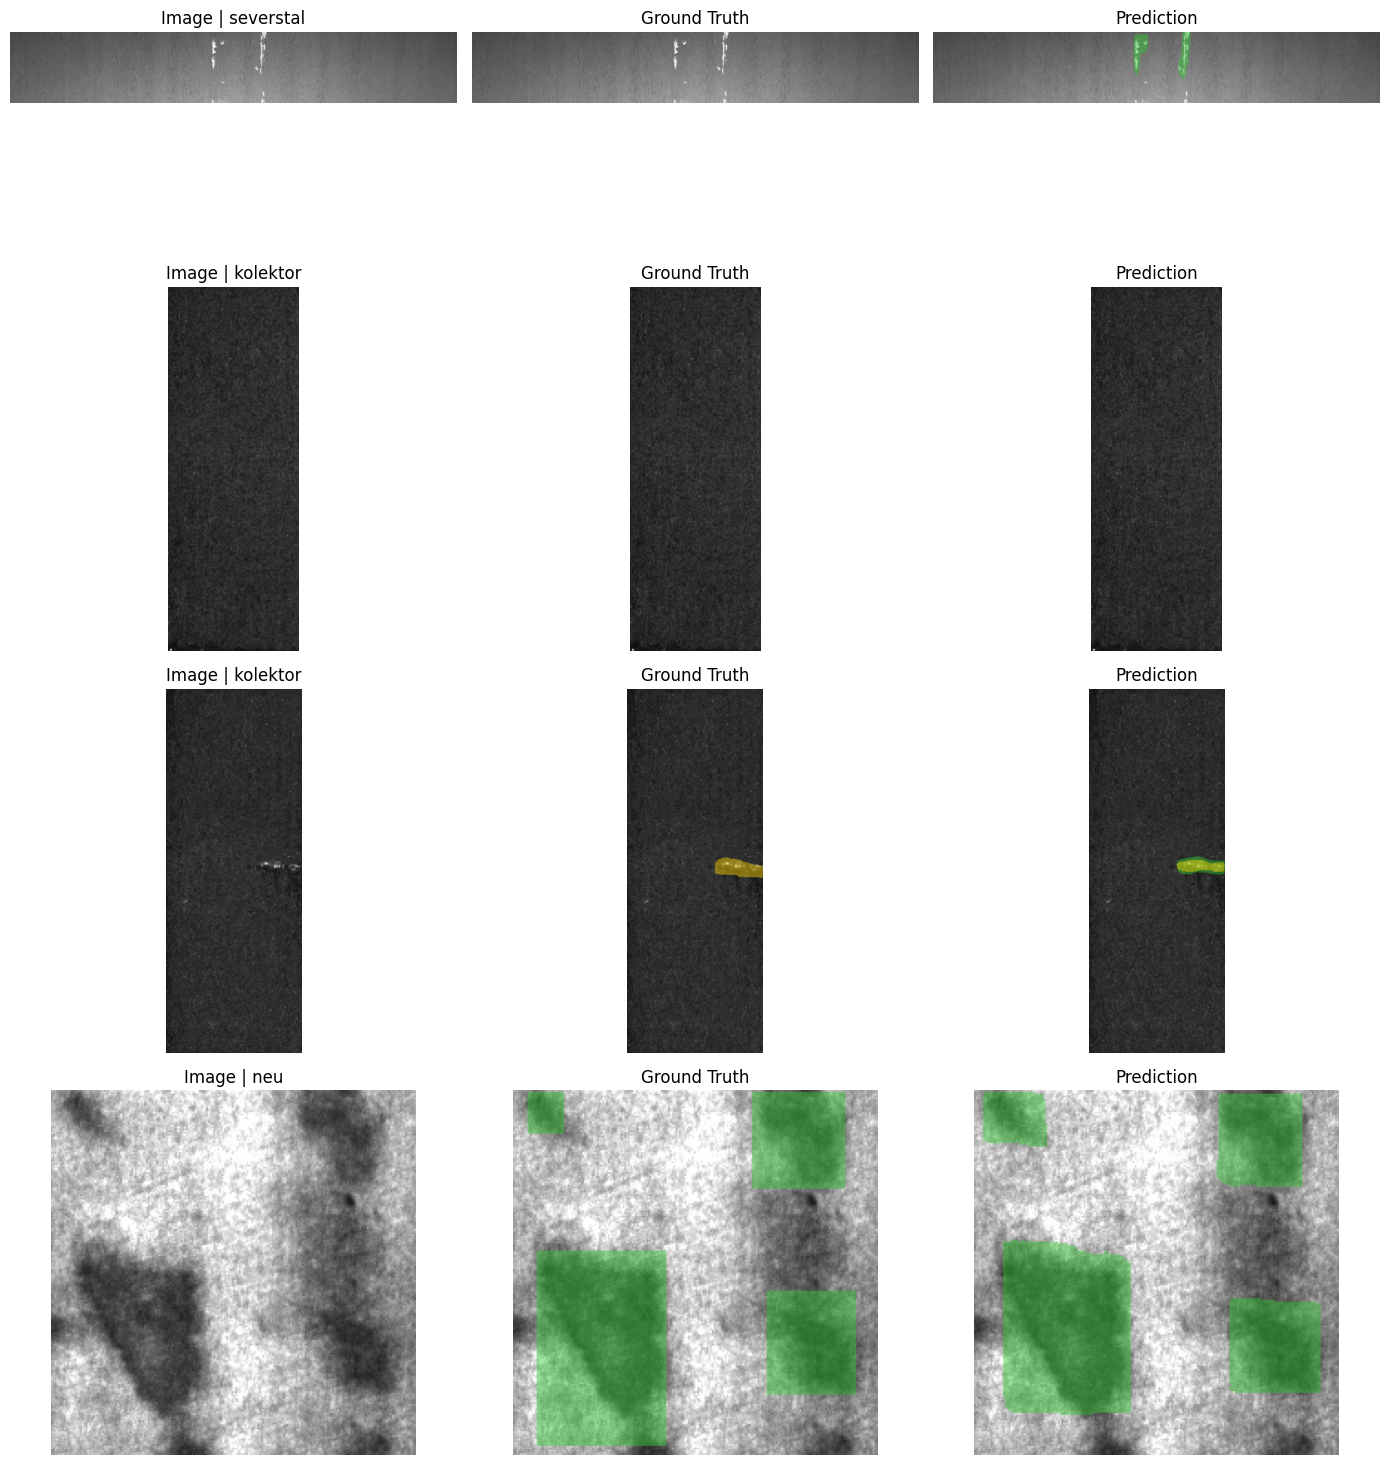

In [26]:
viz_random_state = random.SystemRandom().randint(0, 999999)
print('Visualization random state:', viz_random_state)
viz_records = test_dataset.records.copy()
random.Random(viz_random_state).shuffle(viz_records)
viz_records = viz_records[:min(NUM_VIS_SAMPLES, len(viz_records))]

fig, axes = plt.subplots(len(viz_records), 3, figsize=(14, 4 * len(viz_records)))
if len(viz_records) == 1:
    axes = [axes]

for row_idx, record in enumerate(viz_records):
    image = load_image_as_rgb(record['image_path'])
    image_tensor = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
    true_mask = resize_multiclass_mask(build_mask_from_record(record), tuple(image_tensor.shape[-2:]))
    output = model([image_tensor.to(device)])[0]
    pred_mask = detection_output_to_multiclass_mask(output, image_shape=true_mask.shape[:2], score_threshold=SCORE_THRESHOLD)
    axes[row_idx][0].imshow(image, cmap='gray')
    axes[row_idx][0].set_title(f"Image | {record['source']}")
    axes[row_idx][1].imshow(overlay_multiclass_mask(image, true_mask))
    axes[row_idx][1].set_title('Ground Truth')
    axes[row_idx][2].imshow(overlay_multiclass_mask(image, pred_mask))
    axes[row_idx][2].set_title('Prediction')
    for col_idx in range(3):
        axes[row_idx][col_idx].axis('off')

plt.tight_layout()
plt.savefig('mask_rcnn_test_prediction.png', dpi=150)
plt.show()